In [27]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [92]:
contact = [88, 116]
marker = [102]
j = np.array([[0.15323373, 0.07527931, 0.11386716, -0.02124374],
              [0.00805035, 0.06296659, 0.06940202,  0.05995755]])

n_points:int = 20           # 指定action set离散点数

In [5]:
def generate_polygon(J, theta_start_deg, n_points):
    """Generate a convex polygon by transforming points on a unit semicircle.
    
    Args:
        J (np.ndarray): Jacobian (linear transformation) matrix of shape (2,2).
        theta_start_deg (float): Starting angle in degrees for the semicircle.
            The semicircle is taken as the arc from theta_start_deg to theta_start_deg + 180.
        n_points (int): Number of discretization points along the arc.
         
    Returns:
        np.ndarray: Points array of shape (n_points, 2) containing the vertices
            (in order) of the transformed semicircle (semi-ellipse).
    """
    # Generate angles uniformly in degrees from start to start+180 (inclusive)
    angles_deg = np.linspace(theta_start_deg, theta_start_deg + 180, n_points)
    angles_rad = np.deg2rad(angles_deg)
    
    # Points on the unit semicircle (arc): (cos(theta), sin(theta))
    # These points lie on the arc from theta_start to theta_start+180
    circle_points = np.column_stack((np.cos(angles_rad), np.sin(angles_rad)))
    circle_points = np.vstack((circle_points, np.zeros(2)))
    
    # Transform the points using the Jacobian matrix.
    # Here we use the transformation: new_point = J * point.
    transformed_points = circle_points @ J.T  # using the transpose to match multiplication
    
    return transformed_points

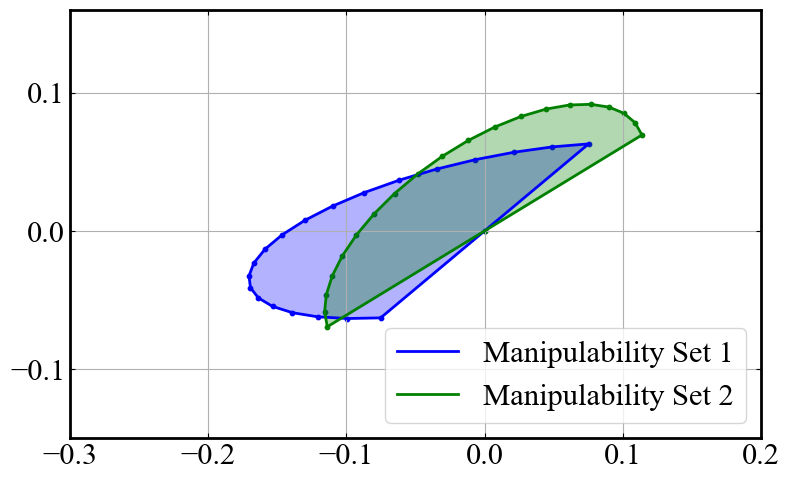

In [102]:
j1 = j[:,:2]
j1_theta = 90.
poly1 = generate_polygon(j1, j1_theta, n_points)
poly1_plot = np.vstack([poly1, poly1[0]])

j2 = j[:,2:]
j2_theta = 0.
poly2 = generate_polygon(j2, j2_theta, n_points)
poly2_plot = np.vstack([poly2, poly2[0]])

fig = plt.figure(figsize=(8, 6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(poly1[:, 0], poly1[:, 1], s=10, c='b', marker='o')
ax.scatter(poly2[:, 0], poly2[:, 1], s=10, c='g', marker='o')
ax.plot(poly1_plot[:, 0], poly1_plot[:, 1], 'b-', lw=2, label='Manipulability Set 1')
ax.fill(poly1_plot[:, 0], poly1_plot[:, 1], 'b', alpha=0.3)
ax.plot(poly2_plot[:, 0], poly2_plot[:, 1], 'g-', lw=2, label='Manipulability Set 2')
ax.fill(poly2_plot[:, 0], poly2_plot[:, 1], 'g', alpha=0.3)
ax.set_xlim(-0.3, 0.2)
ax.set_ylim(-0.15, 0.16)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.legend(fontsize=22, loc="lower right")
ax.tick_params(axis='both', which='major', labelsize=22, direction='in', top=True, right=True)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

for spine in ax.spines.values():
    spine.set_linewidth(2.)

fig.tight_layout()
fig.savefig('manipulability-approx.svg', transparent=True, dpi=300, bbox_inches='tight')

In [115]:
def min_index(poly):
    idx = 0
    for i in range(1, len(poly)):
        if poly[i][0] < poly[idx][0] or (poly[i][0] == poly[idx][0] and poly[i][1] < poly[idx][1]):
            idx = i
    return idx


def cross(a, b):
    return a[0] * b[1] - a[1] * b[0]


def polygon_area(vertices):
    """
    Calculate the area of a convex polygon given its vertices.
    
    Parameters:
    vertices (list of tuples): List of (x, y) coordinates of the polygon vertices in order.
    
    Returns:
    float: The area of the polygon.
    """
    n = len(vertices)
    area = 0.0
    # Loop over all vertices
    for i in range(n):
        x_i, y_i = vertices[i]
        # The next vertex, with wrap-around using modulo
        x_next, y_next = vertices[(i + 1) % n]
        area += x_i * y_next - x_next * y_i
    return abs(area) / 2


def minkowski_sum(poly1, poly2):
    n1 = len(poly1)
    n2 = len(poly2)

    # Find the vertex with the smallest x (and then y) for each polygon.
    i = min_index(poly1)
    j = min_index(poly2)

    # Initialize the Minkowski sum with the sum of the two minimal points.
    res = [poly1[i] + poly2[j]]

    # Merge the edge vectors of poly1 and poly2.
    # The loop runs exactly (n1 + n2) times.
    for _ in range(n1 + n2):
        next_i = (i + 1) % n1
        next_j = (j + 1) % n2
        edge1 = poly1[next_i] - poly1[i]
        edge2 = poly2[next_j] - poly2[j]
        # Choose the edge with the larger polar angle using cross product.
        if cross(edge1, edge2) >= 0:
            res.append(res[-1] + edge1)
            i = next_i
        else:
            res.append(res[-1] + edge2)
            j = next_j

    # Remove the last point if it is the same as the first.
    if np.allclose(res[0], res[-1]):
        res.pop()

    sum_points = np.array(res)

    hull = ConvexHull(sum_points)
    hull_points = sum_points[hull.vertices]
    hull_points = np.vstack([hull_points, hull_points[0]])

    return sum_points, hull_points

manipulability of sum: 6.758464e-02


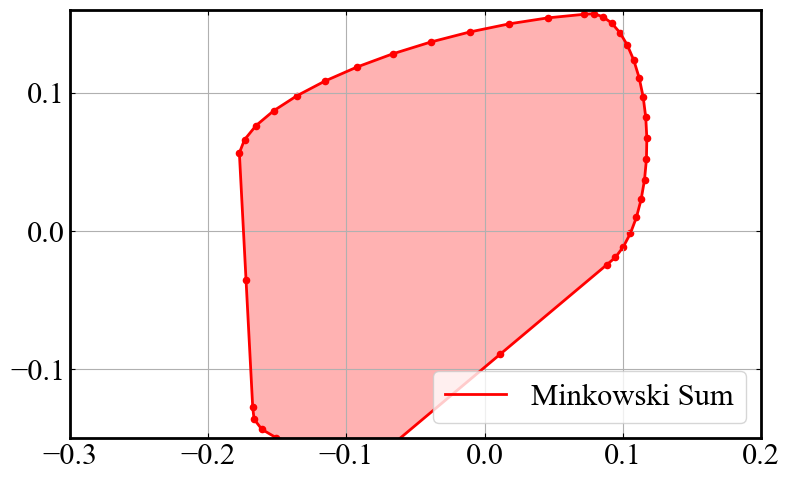

In [118]:
sum_points, hull_points = minkowski_sum(poly1, poly2)
print(f"manipulability of sum: {polygon_area(sum_points):e}")

fig = plt.figure(figsize=(8, 6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(sum_points[:, 0], sum_points[:, 1], s=20, c='r', marker='o')#, label='Poly Vertices')
ax.fill(sum_points[:, 0], sum_points[:, 1], 'r', alpha=0.3)
ax.plot(hull_points[:, 0], hull_points[:, 1], 'r-', lw=2, label='Minkowski Sum')

ax.set_xlim(-0.3, 0.2)
ax.set_ylim(-0.15, 0.16)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.legend(fontsize=22, loc="lower right")
ax.tick_params(axis='both', which='major', labelsize=22, direction='in', top=True, right=True)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

for spine in ax.spines.values():
    spine.set_linewidth(2)

fig.tight_layout()
fig.savefig('minkowski-add.svg', transparent=True, dpi=300, bbox_inches='tight')

Determinant: 1.868417e-03; 4.598589e-03; 1.813150e-02


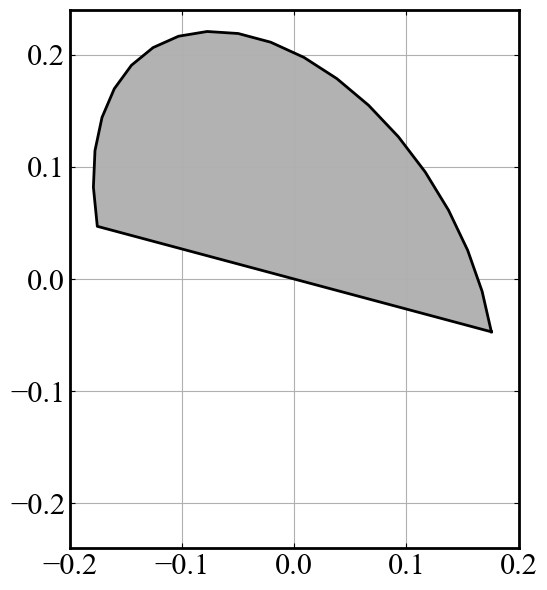

In [112]:
# j = np.array([[0.00877361,  0.01557084,  0.15389461,  0.076358,    0.12240066, -0.03045141],
#             [0.00601206,  0.03180721,  0.00883393,  0.062856,    0.03234459,  0.03678397]])
j = np.array([[ 0.04005426, -0.00483686,  0.1547557,   0.0770685,  0.17574952, -0.03569749],
            [ 0.01004689,  0.09208105, 0.01054479,  0.06468162, -0.04704813,  0.21588959]])

j1, j2, j3 = j[:, :2], j[:, 2:4], j[:, 4:]
j1_theta, j2_theta, j3_theta = -90, 90, 0.
print(f"Determinant: {np.linalg.det(j1)/2:e}; {np.linalg.det(j2)/2:e}; {np.linalg.det(j3)/2:e}")

poly1 = generate_polygon(j1, j1_theta, n_points)
poly2 = generate_polygon(j2, j2_theta, n_points)
poly3 = generate_polygon(j3, j3_theta, n_points)
poly1_plot = np.vstack([poly1, poly1[0]])
poly2_plot = np.vstack([poly2, poly2[0]])
poly3_plot = np.vstack([poly3, poly3[0]])


fig = plt.figure(figsize=(8, 6), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
# ax.scatter(poly1[:, 0], poly1[:, 1], s=10, c='k', marker='o')
# ax.plot(poly1_plot[:, 0], poly1_plot[:, 1], 'k-', lw=2, label='Manipulability Set 1')
# ax.fill(poly1_plot[:, 0], poly1_plot[:, 1], 'k', alpha=0.3)

# ax.plot(poly2_plot[:, 0], poly2_plot[:, 1], 'k-', lw=2, label='Manipulability Set 2')
# ax.fill(poly2_plot[:, 0], poly2_plot[:, 1], 'k', alpha=0.3)

ax.plot(poly3_plot[:, 0], poly3_plot[:, 1], 'k-', lw=2, label='Manipulability Set 3')
ax.fill(poly3_plot[:, 0], poly3_plot[:, 1], 'k', alpha=0.3)

ax.set_xlim(-0.2, 0.2)
ax.set_ylim(-0.24, 0.24)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
# ax.legend(fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=22, direction='in', top=True, right=True)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

for spine in ax.spines.values():
    spine.set_linewidth(2)

fig.tight_layout()
fig.savefig('manipulability-3.svg', transparent=True, dpi=300, bbox_inches='tight')